### A1 — Create a NumPy array using `arange`

**What this block does:**
- Uses `np.arange(start, stop, step)` to generate values.
- Starts at `1`, goes up to **before** `21` (so max is 19), and jumps by `3`.
- Stores the result into `arr` and prints it.


In [1]:
import numpy as np

arr = np.arange(1, 21, 3)
arr


array([ 1,  4,  7, 10, 13, 16, 19])

### A2 — Generate a random array of length 3

**What this block does:**
- Fixes the random seed for consistent output across runs.
- Uses `np.random.rand(3)` to generate 3 random float values between 0 and 1.
- Stores it in `rand_arr`.


In [2]:
np.random.seed(42)
rand_arr = np.random.rand(3)
rand_arr


array([0.37454012, 0.95071431, 0.73199394])

### A3 — Create a 3x3 matrix and slice it

**What this block does:**
- Builds a 3x3 matrix `A`.
- Extracts:
  - the **first two rows**
  - the **last two rows**
- Demonstrates row slicing using NumPy indexing.


In [3]:
A = np.array([
    [10, 20, 45],
    [30, 12, 16],
    [42, 17, 56]
])

first_two_rows = A[:2, :]
last_two_rows = A[-2:, :]

A, first_two_rows, last_two_rows


(array([[10, 20, 45],
        [30, 12, 16],
        [42, 17, 56]]),
 array([[10, 20, 45],
        [30, 12, 16]]),
 array([[30, 12, 16],
        [42, 17, 56]]))

### A4 — Stack arrays vertically and horizontally

**What this block does:**
- Creates two 2x2 matrices: `B` and `C`.
- Uses:
  - `np.vstack()` to stack them **on top of each other** → shape becomes 4x2
  - `np.hstack()` to stack them **side by side** → shape becomes 2x4


In [4]:
B = np.array([[1, 2],
              [3, 4]])

C = np.array([[5, 6],
              [7, 8]])

vertical_stack = np.vstack((B, C))
horizontal_stack = np.hstack((B, C))

B, C, vertical_stack, horizontal_stack


(array([[1, 2],
        [3, 4]]),
 array([[5, 6],
        [7, 8]]),
 array([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]]),
 array([[1, 2, 5, 6],
        [3, 4, 7, 8]]))

### A5 — Split stacked arrays into equal parts

**What this block does:**
- Splits the vertical stack into 2 blocks using `np.vsplit()`
- Splits the horizontal stack into 2 blocks using `np.hsplit()`
- Produces lists of smaller matrices (useful for batching and partitioning data).


In [5]:
v_split = np.vsplit(vertical_stack, 2)   # returns two 2x2 arrays
h_split = np.hsplit(horizontal_stack, 2) # returns two 2x2 arrays

v_split, h_split


([array([[1, 2],
         [3, 4]]),
  array([[5, 6],
         [7, 8]])],
 [array([[1, 2],
         [3, 4]]),
  array([[5, 6],
         [7, 8]])])

### A6 — Matrix multiplication feasibility + execution

**What this block does:**
- Creates matrices `X` (3x3) and `Y` (3x2).
- Prints their shapes to confirm dimension compatibility.
- Performs multiplication `X @ Y` because inner dimensions match (3 and 3).
- Demonstrates an invalid multiplication `Y @ X` inside `try/except`.


In [6]:
X = np.array([[5, 7, 2],
              [4, 5, 6],
              [7, 4, 2]])

Y = np.array([[4, 2],
              [6, 2],
              [4, 2]])

print("X shape:", X.shape)
print("Y shape:", Y.shape)

XY = X @ Y
print("\nX @ Y result:\n", XY)

try:
    YX = Y @ X
    print("\nY @ X result:\n", YX)
except ValueError as e:
    print("\nY @ X is not possible:", e)


X shape: (3, 3)
Y shape: (3, 2)

X @ Y result:
 [[70 28]
 [70 30]
 [60 26]]

Y @ X is not possible: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)


### A7 — Shape, dimensions, and reshaping vectors

**What this block does:**
- Creates two 1D vectors `x` and `y`.
- Prints:
  - shape (length)
  - dimensions (`ndim`)
- Reshapes both vectors into (3x1) column vectors using `.reshape(3,1)`.
- This is often needed for matrix math and ML pipelines.


In [7]:
x = np.array([2, -1, -8])
y = np.array([3, 1, -2])

print("x:", x, "| shape:", x.shape, "| ndim:", x.ndim)
print("y:", y, "| shape:", y.shape, "| ndim:", y.ndim)

x_reshaped = x.reshape(3, 1)
y_reshaped = y.reshape(3, 1)

print("\nReshaped x:\n", x_reshaped, "| shape:", x_reshaped.shape, "| ndim:", x_reshaped.ndim)
print("\nReshaped y:\n", y_reshaped, "| shape:", y_reshaped.shape, "| ndim:", y_reshaped.ndim)


x: [ 2 -1 -8] | shape: (3,) | ndim: 1
y: [ 3  1 -2] | shape: (3,) | ndim: 1

Reshaped x:
 [[ 2]
 [-1]
 [-8]] | shape: (3, 1) | ndim: 2

Reshaped y:
 [[ 3]
 [ 1]
 [-2]] | shape: (3, 1) | ndim: 2


### A8 — Broadcasting with subtraction and multiplication

**What this block does:**
- Creates a 3x3 matrix `M` and a vector `v` with 3 values.
- Uses broadcasting:
  - `M - v` subtracts the vector from each row
  - `M * v` multiplies each row by the vector
- Also demonstrates column broadcasting using a (3x1) column vector.


In [8]:
M = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

v = np.array([10, 20, 30])

sub_result = M - v
mul_result = M * v

col = np.array([[2],
                [3],
                [4]])

col_add_result = M + col

M, v, sub_result, mul_result, col_add_result


(array([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]),
 array([10, 20, 30]),
 array([[ -9, -18, -27],
        [ -6, -15, -24],
        [ -3, -12, -21]]),
 array([[ 10,  40,  90],
        [ 40, 100, 180],
        [ 70, 160, 270]]),
 array([[ 3,  4,  5],
        [ 7,  8,  9],
        [11, 12, 13]]))

### A9 — Visualization (Two simple graphs)

**What this block does:**
- Graph 1: Plots the `arr` sequence as a line plot (trend view).
- Graph 2: Displays matrix `M` as a heatmap (pattern and scale view).
- These visuals help validate data structure and detect anomalies early.


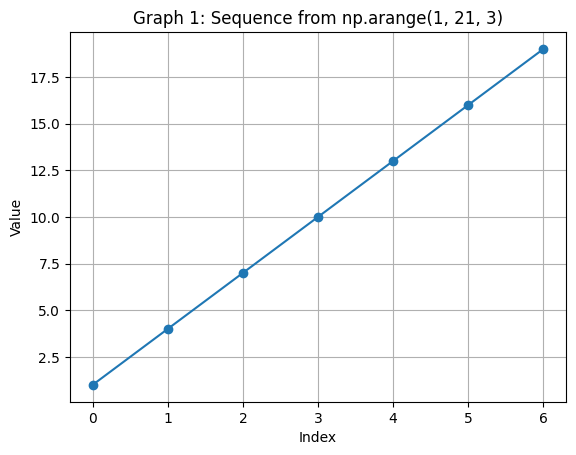

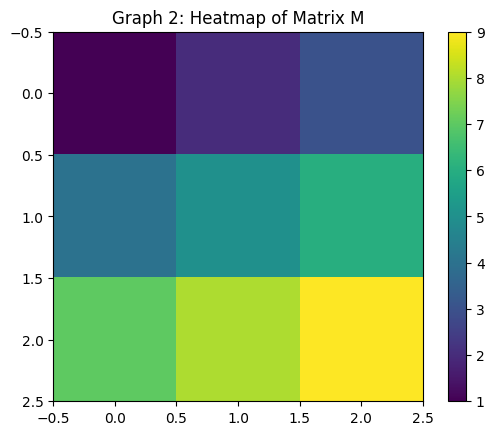

In [9]:
import matplotlib.pyplot as plt

# Graph 1
plt.figure()
plt.plot(arr, marker="o")
plt.title("Graph 1: Sequence from np.arange(1, 21, 3)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

# Graph 2
plt.figure()
plt.imshow(M)
plt.title("Graph 2: Heatmap of Matrix M")
plt.colorbar()
plt.show()


### B0 — Helper function to classify solutions

**What this block does:**
- Defines a function that compares:
  - rank(A)
  - rank([A|b]) (augmented matrix)
- Uses rank rules:
  - rank(A) != rank([A|b]) → No solution
  - rank(A) == rank([A|b]) == number_of_variables → Unique solution
  - rank(A) == rank([A|b]) < number_of_variables → Infinite solutions


In [10]:
def solution_type(A, b):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float).reshape(-1, 1)
    aug = np.hstack([A, b])

    rA = np.linalg.matrix_rank(A)
    rAug = np.linalg.matrix_rank(aug)
    n = A.shape[1]

    if rA != rAug:
        return "No solution", rA, rAug, n
    elif rA == n:
        return "Unique solution", rA, rAug, n
    else:
        return "Infinite solutions", rA, rAug, n


### B1 — Classify system 1 and compute one valid solution

**What this block does:**
- Builds coefficient matrix `A1` and constant vector `b1`.
- Uses the rank method to classify the solution type.
- Since it's not a square system (2 equations, 3 unknowns), we compute a valid solution using least squares (`np.linalg.lstsq`).
- Prints the estimate and verifies by multiplying A1 @ x.


In [11]:
A1 = [[2, 3, -4],
      [1, -4, 0]]

b1 = [6, 8]

stype1, rA1, rAug1, n1 = solution_type(A1, b1)
print("System 1 solution type:", stype1)
print("rank(A) =", rA1, "| rank([A|b]) =", rAug1, "| variables =", n1)

x_sol1, residuals1, rank1, s1 = np.linalg.lstsq(np.array(A1, float), np.array(b1, float), rcond=None)
print("\nOne valid solution estimate (least squares):", x_sol1)

print("\nCheck A1 @ x ≈ b1:")
print(np.array(A1, float) @ x_sol1)
print(np.array(b1, float))


System 1 solution type: Infinite solutions
rank(A) = 2 | rank([A|b]) = 2 | variables = 3

One valid solution estimate (least squares): [ 1.6692112 -1.5826972 -1.8524173]

Check A1 @ x ≈ b1:
[6. 8.]
[6. 8.]


### B2 — Classify system 2 and compute one valid solution

**What this block does:**
- Builds coefficient matrix `A2` and constant vector `b2`.
- Classifies the system using rank comparison.
- Computes a valid solution using least squares (`np.linalg.lstsq`) because it’s again underdetermined (2 equations, 3 unknowns).
- Verifies the solution by checking A2 @ y.


In [12]:
A2 = [[3, -4, 5],
      [-1, 2, -4]]

b2 = [10, 8]

stype2, rA2, rAug2, n2 = solution_type(A2, b2)
print("System 2 solution type:", stype2)
print("rank(A) =", rA2, "| rank([A|b]) =", rAug2, "| variables =", n2)

y_sol2, residuals2, rank2, s2 = np.linalg.lstsq(np.array(A2, float), np.array(b2, float), rcond=None)
print("\nOne valid solution estimate (least squares):", y_sol2)

print("\nCheck A2 @ y ≈ b2:")
print(np.array(A2, float) @ y_sol2)
print(np.array(b2, float))


System 2 solution type: Infinite solutions
rank(A) = 2 | rank([A|b]) = 2 | variables = 3

One valid solution estimate (least squares): [ 7.46067416 -4.62921348 -6.17977528]

Check A2 @ y ≈ b2:
[10.  8.]
[10.  8.]
